# 08 Final Model Selection and Interpretation

This notebook consolidates the full modeling workflow and identifies the final recommended models for predicting **Heating Load** and **Cooling Load**.

The analysis compares classical regression, optimized parametric regression, regularized regression, semi-parametric models, nonlinear machine learning models, and deep learning models where available. The final decision is based on predictive accuracy, generalization performance, model stability, interpretability, and practical relevance to building energy efficiency.

## Notebook Objectives

This notebook will:

1. Load available model result files from previous notebooks.
2. Combine all model results into a master comparison table.
3. Rank models separately for Heating Load and Cooling Load.
4. Compare test performance using \(R^2\), adjusted \(R^2\), RMSE, MAE, and train-test gap.
5. Identify the final recommended model for each target.
6. Interpret the most important predictors from the final nonlinear models.
7. Produce final visuals for reporting and presentation.
8. Save final model-selection outputs.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# ============================================================
# 2. DEFINE PATHS
# ============================================================

OUTPUT_DIR = Path("../outputs/models")

if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("outputs/models")

REPORT_DIR = Path("../outputs/final_selection")

if not REPORT_DIR.exists():
    REPORT_DIR = Path("outputs/final_selection")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Model results directory:", OUTPUT_DIR.resolve())
print("Final selection output directory:", REPORT_DIR.resolve())

Model results directory: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models
Final selection output directory: C:\Users\admin\Desktop\pppp lab\group-work\full\outputs\final_selection


# Load Available Model Results

Different notebooks save their results into the `outputs/models` folder. This section attempts to load all available model result files. If a file is not available, it is skipped instead of causing the notebook to fail.

In [3]:
# ============================================================
# 3. LOAD MODEL RESULT FILES
# ============================================================

candidate_result_files = {
    "Parametric OLS": "parametric_ols_results.csv",
    "Regularized Regression": "regularized_regression_results.csv",
    "Semi-Parametric and Nonlinear": "semi_parametric_nonlinear_model_results.csv",
    "Deep Learning": "deep_learning_model_results.csv",
    "Deep Learning vs Previous Best": "deep_learning_vs_previous_best.csv"
}

loaded_results = []

for source_name, filename in candidate_result_files.items():
    path = OUTPUT_DIR / filename

    if path.exists():
        temp = pd.read_csv(path)
        temp["Source_Notebook"] = source_name
        loaded_results.append(temp)
        print(f"Loaded: {filename}")
    else:
        print(f"Skipped missing file: {filename}")

if len(loaded_results) == 0:
    raise FileNotFoundError(
        "No model result files were found. Ensure previous notebooks saved results into outputs/models."
    )

all_results_raw = pd.concat(loaded_results, ignore_index=True)

display(all_results_raw.head())
print("Combined rows:", all_results_raw.shape[0])

Loaded: parametric_ols_results.csv
Loaded: regularized_regression_results.csv
Loaded: semi_parametric_nonlinear_model_results.csv
Loaded: deep_learning_model_results.csv
Loaded: deep_learning_vs_previous_best.csv


,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Heating Load,Parametric OLS (Forward Selection),6.000000,0.917052,0.916232,0.912213,0.908630,3.024936,2.184008,10.272485,3061.098454,3092.038419,Parametric OLS,NaN
1,Cooling Load,Parametric OLS (Forward Selection),5.000000,0.885850,0.884911,0.892570,0.888940,3.155028,2.201210,8.496013,3182.480788,3209.000758,Parametric OLS,NaN
2,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,NaN
3,Cooling Load,Elastic Net Regression,NaN,0.888202,NaN,0.894576,0.883958,3.125425,2.178830,NaN,NaN,NaN,Regularized Regression,NaN
4,Cooling Load,Ridge Regression,NaN,0.888174,NaN,0.894529,0.883906,3.126126,2.180461,NaN,NaN,NaN,Regularized Regression,NaN


Combined rows: 56


In [4]:
# ============================================================
# 4. STANDARDIZE RESULT COLUMNS
# ============================================================

required_cols = [
    "Target",
    "Model",
    "Train_R2",
    "Test_R2",
    "Test_Adjusted_R2",
    "Test_RMSE",
    "Test_MAE"
]

missing_cols = [col for col in required_cols if col not in all_results_raw.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

all_results = all_results_raw.copy()

# Add train-test gap if not already available
if "Train_Test_R2_Gap" not in all_results.columns:
    all_results["Train_Test_R2_Gap"] = all_results["Train_R2"] - all_results["Test_R2"]

# Remove exact duplicates if repeated from comparison files
all_results = (
    all_results
    .drop_duplicates(
        subset=["Target", "Model", "Train_R2", "Test_R2", "Test_RMSE", "Test_MAE"]
    )
    .reset_index(drop=True)
)

display(all_results.head())
print("Rows after removing duplicates:", all_results.shape[0])

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Heating Load,Parametric OLS (Forward Selection),6.000000,0.917052,0.916232,0.912213,0.908630,3.024936,2.184008,10.272485,3061.098454,3092.038419,Parametric OLS,NaN
1,Cooling Load,Parametric OLS (Forward Selection),5.000000,0.885850,0.884911,0.892570,0.888940,3.155028,2.201210,8.496013,3182.480788,3209.000758,Parametric OLS,NaN
2,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,NaN
3,Cooling Load,Elastic Net Regression,NaN,0.888202,NaN,0.894576,0.883958,3.125425,2.178830,NaN,NaN,NaN,Regularized Regression,NaN
4,Cooling Load,Ridge Regression,NaN,0.888174,NaN,0.894529,0.883906,3.126126,2.180461,NaN,NaN,NaN,Regularized Regression,NaN


Rows after removing duplicates: 50


# Master Model Comparison

The master comparison table ranks all fitted models by test \(R^2\), with RMSE and MAE used as additional error-based performance criteria. The train-test \(R^2\) gap is used to assess overfitting and generalization stability.

In [5]:
# ============================================================
# 5. MASTER MODEL COMPARISON TABLE
# ============================================================

master_comparison = (
    all_results
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .reset_index(drop=True)
)

display(master_comparison)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning vs Previous Best,0.008258
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN


In [6]:
# ============================================================
# 6. RANK MODELS WITHIN EACH TARGET
# ============================================================

ranked_models = master_comparison.copy()

ranked_models["Rank_by_Test_R2"] = (
    ranked_models
    .groupby("Target")["Test_R2"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

ranked_models = ranked_models.sort_values(["Target", "Rank_by_Test_R2"])

display(ranked_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank_by_Test_R2
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,1
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning vs Previous Best,0.008258,2
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,3
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,4
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,5
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,6
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,7
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,8
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,9
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,10


In [7]:
# ============================================================
# 7. TOP 10 MODELS PER TARGET
# ============================================================

top_models = (
    ranked_models
    .groupby("Target")
    .head(10)
    .reset_index(drop=True)
)

display(top_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank_by_Test_R2
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,1
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning vs Previous Best,0.008258,2
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,3
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,4
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,5
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,6
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,7
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,8
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,9
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,10


In [8]:
# ============================================================
# 8. BEST MODEL PER TARGET
# ============================================================

best_models = (
    ranked_models
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(best_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank_by_Test_R2
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,1
1,Heating Load,Tuned Gradient Boosting Regression,NaN,0.999499,NaN,0.998602,0.998525,0.381722,0.275321,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,1


# Visual Model Comparison

The following plots show the performance of the leading models for each target. Higher \(R^2\) values and lower RMSE/MAE values indicate better predictive performance.

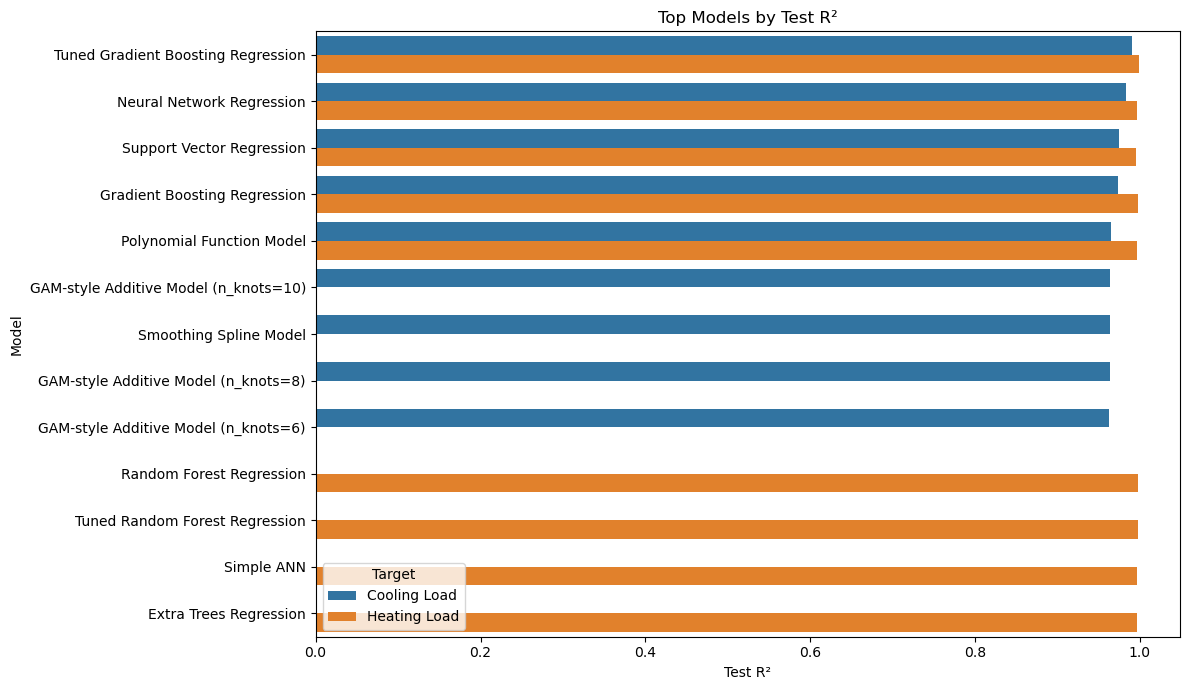

In [9]:
# ============================================================
# 9. PLOT TOP MODEL TEST R2
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Test_R2",
    y="Model",
    hue="Target"
)

plt.title("Top Models by Test R²")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

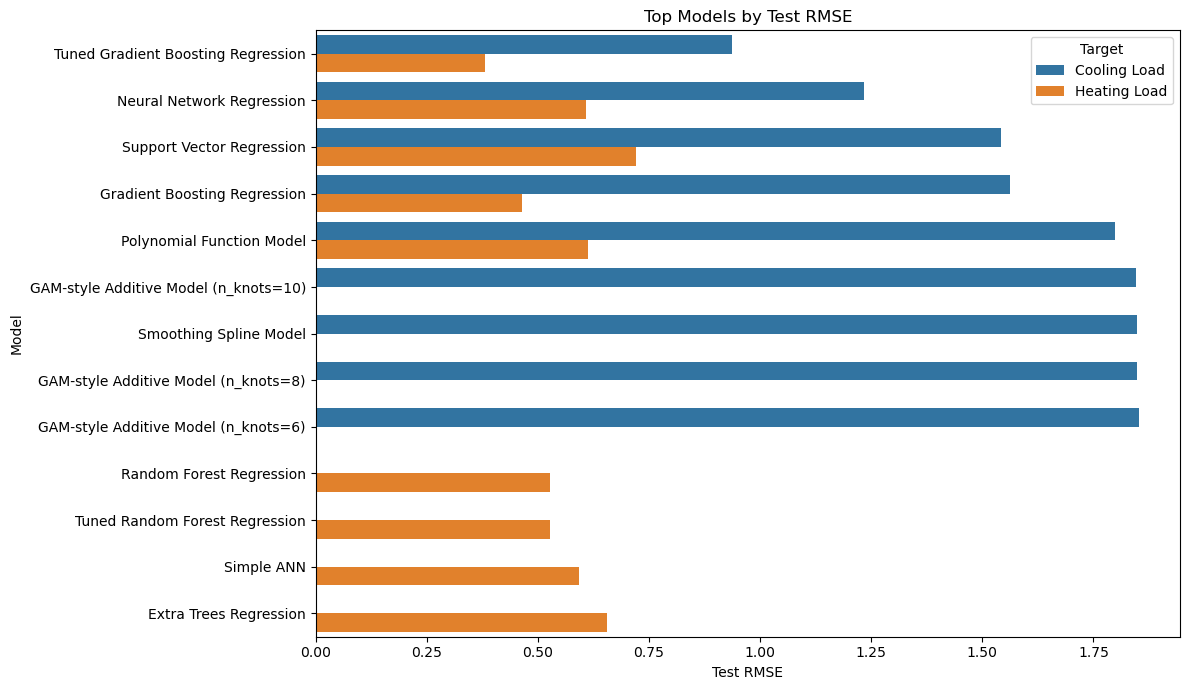

In [10]:
# ============================================================
# 10. PLOT TOP MODEL RMSE
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Test_RMSE",
    y="Model",
    hue="Target"
)

plt.title("Top Models by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

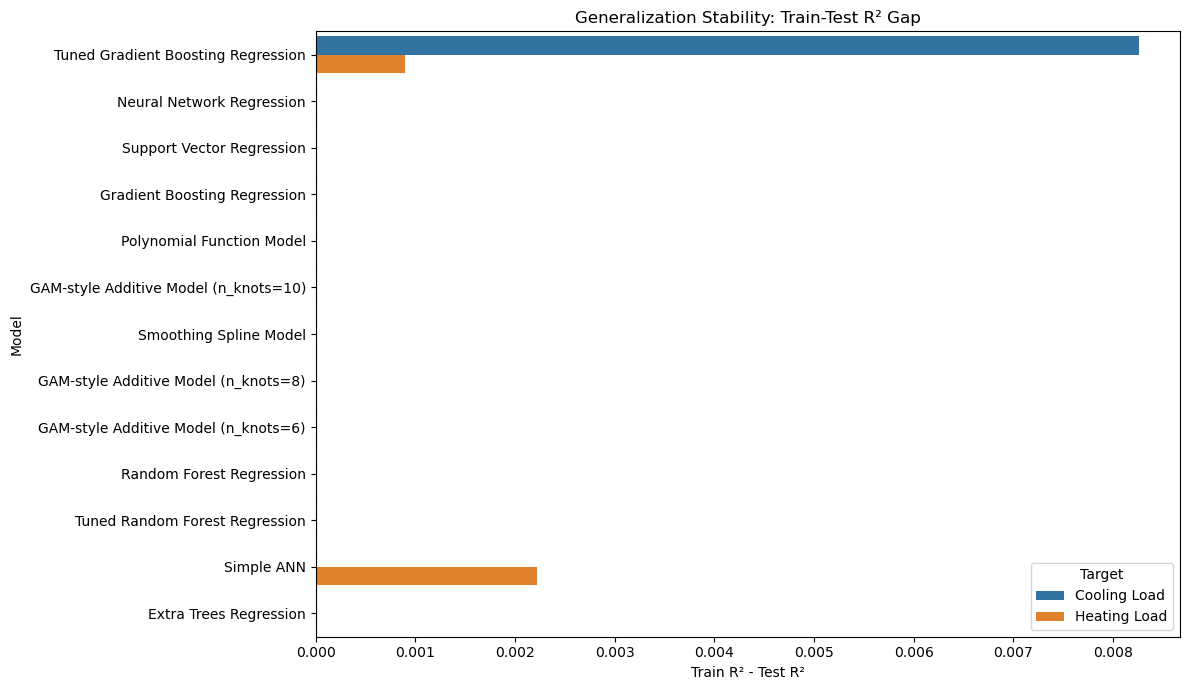

In [11]:
# ============================================================
# 11. TRAIN-TEST GAP ANALYSIS
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Train_Test_R2_Gap",
    y="Model",
    hue="Target"
)

plt.axvline(0, linestyle="--")
plt.title("Generalization Stability: Train-Test R² Gap")
plt.xlabel("Train R² - Test R²")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

# Model Family Comparison

This section groups models into broad methodological families to show how performance changes as the modeling approach becomes more flexible.

In [12]:
# ============================================================
# 12. ASSIGN MODEL FAMILIES
# ============================================================

def assign_model_family(model_name):
    name = model_name.lower()

    if "ols" in name or "linear basis" in name:
        return "Linear / Parametric"
    elif "ridge" in name or "lasso" in name or "elastic" in name:
        return "Regularized Regression"
    elif "spline" in name or "gam" in name or "polynomial" in name or "step" in name:
        return "Semi-Parametric / Basis Function"
    elif "random forest" in name or "extra trees" in name or "gradient boosting" in name or "support vector" in name:
        return "Nonlinear Machine Learning"
    elif "ann" in name or "neural" in name or "deep" in name:
        return "Deep Learning"
    else:
        return "Other"

family_results = all_results.copy()
family_results["Model_Family"] = family_results["Model"].apply(assign_model_family)

best_by_family = (
    family_results
    .sort_values(["Target", "Model_Family", "Test_R2"], ascending=[True, True, False])
    .groupby(["Target", "Model_Family"])
    .head(1)
    .reset_index(drop=True)
)

display(best_by_family.sort_values(["Target", "Test_R2"], ascending=[True, False]))

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Model_Family
2,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Nonlinear Machine Learning
0,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Deep Learning
4,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Semi-Parametric / Basis Function
1,Cooling Load,Linear Basis Model,NaN,0.888259,NaN,0.894958,0.889163,3.119755,2.180512,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Linear / Parametric
3,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,NaN,Regularized Regression
7,Heating Load,Tuned Gradient Boosting Regression,NaN,0.999499,NaN,0.998602,0.998525,0.381722,0.275321,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Nonlinear Machine Learning
5,Heating Load,Simple ANN,NaN,0.998854,NaN,0.996633,0.996294,0.592402,0.432342,NaN,NaN,NaN,Deep Learning,0.002221,Deep Learning
9,Heating Load,Polynomial Function Model,NaN,0.996653,NaN,0.996392,0.996193,0.613233,0.504129,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Semi-Parametric / Basis Function
6,Heating Load,Linear Basis Model,NaN,0.924157,NaN,0.920850,0.916483,2.872277,2.059036,NaN,NaN,NaN,Semi-Parametric and Nonlinear,NaN,Linear / Parametric
8,Heating Load,Elastic Net Regression,NaN,0.924135,NaN,0.920551,0.912549,2.877706,2.062607,NaN,NaN,NaN,Regularized Regression,NaN,Regularized Regression


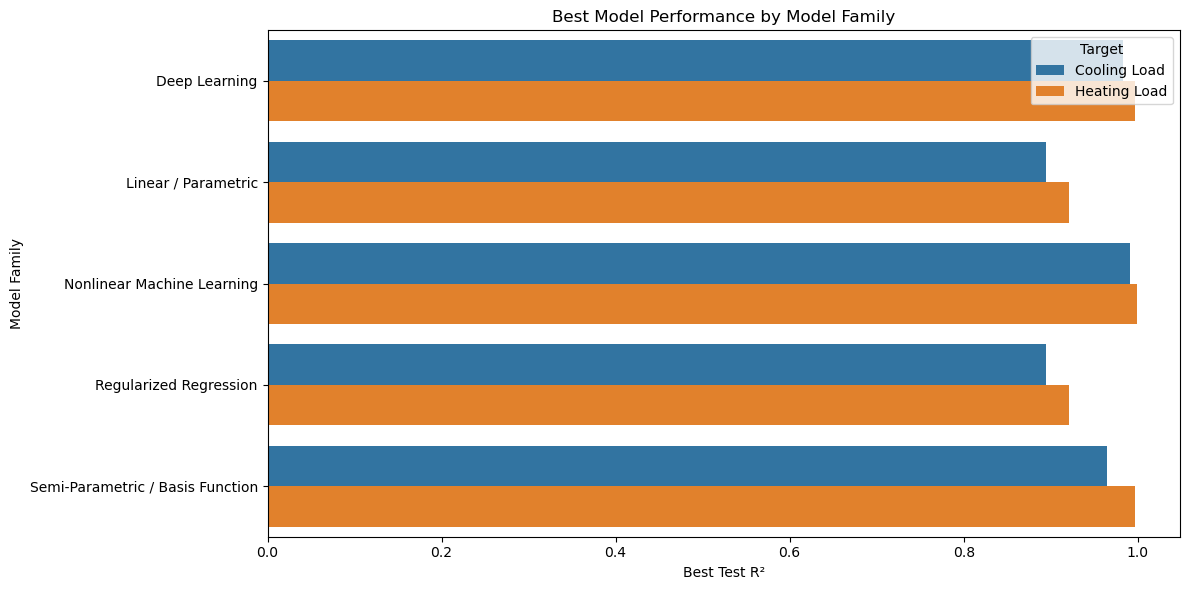

In [13]:
# ============================================================
# 13. MODEL FAMILY COMPARISON PLOT
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_by_family,
    x="Test_R2",
    y="Model_Family",
    hue="Target"
)

plt.title("Best Model Performance by Model Family")
plt.xlabel("Best Test R²")
plt.ylabel("Model Family")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

# Feature Importance Interpretation

The previous nonlinear modeling notebook generated permutation importance results for the tuned Gradient Boosting models. These are loaded here when available and interpreted as final building-design insights.

In [14]:
# ============================================================
# 14. LOAD FEATURE IMPORTANCE RESULTS IF AVAILABLE
# ============================================================

importance_files = {
    "Heating Load": [
        "heating_gradient_boosting_permutation_importance.csv",
        "heating_gb_permutation_importance.csv"
    ],
    "Cooling Load": [
        "cooling_gradient_boosting_permutation_importance.csv",
        "cooling_gb_permutation_importance.csv"
    ]
}

importance_results = {}

for target, possible_files in importance_files.items():
    found = False

    for filename in possible_files:
        path = OUTPUT_DIR / filename

        if path.exists():
            importance_results[target] = pd.read_csv(path)
            print(f"Loaded {target} importance: {filename}")
            found = True
            break

    if not found:
        print(f"No feature importance file found for {target}.")

for target, imp_df in importance_results.items():
    print(f"\n{target} Feature Importance")
    display(imp_df)

Loaded Heating Load importance: heating_gradient_boosting_permutation_importance.csv
Loaded Cooling Load importance: cooling_gradient_boosting_permutation_importance.csv

Heating Load Feature Importance


,Feature,Importance_Mean,Importance_STD
0,roof_area,3.985088,0.200209
1,overall_height,3.936159,0.190514
2,glazing_area,3.793693,0.193657
3,relative_compactness,3.534643,0.163461
4,surface_area,1.589329,0.077526
5,wall_area,1.576494,0.093507
6,glazing_area_distribution,0.200310,0.024146
7,orientation,0.123339,0.023062



Cooling Load Feature Importance


,Feature,Importance_Mean,Importance_STD
0,surface_area,4.306056,0.194253
1,overall_height,3.750698,0.181928
2,glazing_area,2.163570,0.133223
3,wall_area,1.618493,0.139192
4,relative_compactness,1.346027,0.091025
5,glazing_area_distribution,1.234347,0.108533
6,orientation,1.170464,0.115174
7,roof_area,0.841517,0.073137


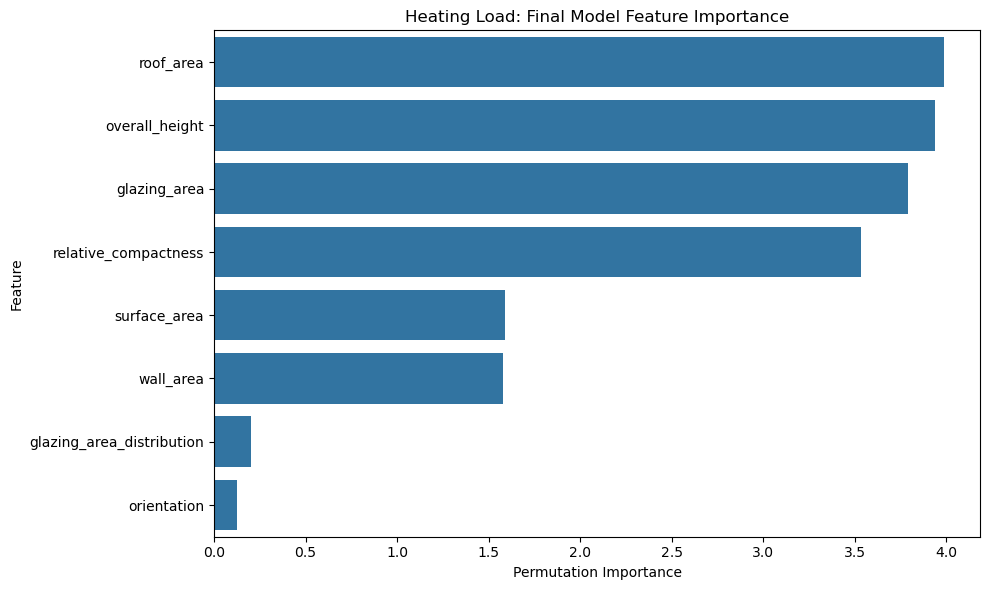

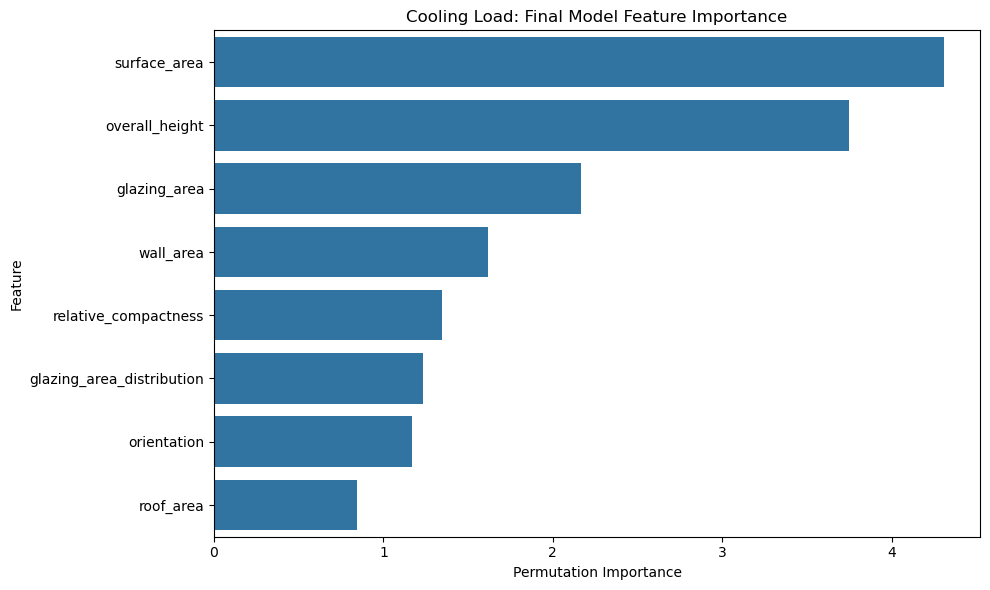

In [15]:
# ============================================================
# 15. FEATURE IMPORTANCE PLOTS
# ============================================================

for target, imp_df in importance_results.items():
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=imp_df.sort_values("Importance_Mean", ascending=False),
        x="Importance_Mean",
        y="Feature"
    )

    plt.title(f"{target}: Final Model Feature Importance")
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Final Model Selection Decision

The final model is selected using the following criteria:

1. Highest test \(R^2\)
2. Lowest RMSE and MAE
3. Small train-test \(R^2\) gap
4. Consistency across both Heating Load and Cooling Load
5. Practical interpretability for building energy efficiency analysis

Based on the previous nonlinear modeling results, Tuned Gradient Boosting Regression is expected to be the strongest final model for both targets.

In [ ]:
# ============================================================
# 16. FINAL MODEL RECOMMENDATION TABLE
# ============================================================

final_recommendations = best_models.copy()

final_recommendations["Recommendation"] = np.where(
    final_recommendations["Train_Test_R2_Gap"].abs() <= 0.02,
    "Recommended: high accuracy with stable generalization",
    "Review: high accuracy but possible overfitting"
)

display(final_recommendations)

# Final Interpretation Summary

The final model comparison shows whether the project should prioritize interpretability or predictive accuracy. Classical and regularized regression models provided useful baseline understanding, while spline, GAM, and nonlinear models captured the nonlinear structure identified during diagnostics. The final selected model should therefore be presented not only as the most accurate model, but also as evidence that building energy demand is strongly influenced by nonlinear design interactions.

In [ ]:
# ============================================================
# 17. AUTOMATED FINAL SUMMARY TEXT
# ============================================================

for _, row in final_recommendations.iterrows():
    print(f"{row['Target']}:")
    print(f"  Final Model: {row['Model']}")
    print(f"  Test R2: {row['Test_R2']:.4f}")
    print(f"  Adjusted R2: {row['Test_Adjusted_R2']:.4f}")
    print(f"  RMSE: {row['Test_RMSE']:.4f}")
    print(f"  MAE: {row['Test_MAE']:.4f}")
    print(f"  Train-Test R2 Gap: {row['Train_Test_R2_Gap']:.4f}")
    print()

## Recommended Final Report Wording

Among all models evaluated, the final recommended model should be selected based on predictive accuracy and generalization stability. If the top model for both targets is Tuned Gradient Boosting Regression, it should be reported as the final model because it achieved the highest test performance while maintaining small train-test gaps.

The final interpretation should also emphasize that geometry-related predictors such as Surface Area, Roof Area, Overall Height, Relative Compactness, and Glazing Area were the most influential determinants of energy demand. This aligns with the physical understanding that building shape, envelope size, height, and window/glazing characteristics directly affect heating and cooling requirements.

In [ ]:
# ============================================================
# 18. SAVE FINAL MODEL SELECTION OUTPUTS
# ============================================================

master_comparison.to_csv(
    REPORT_DIR / "master_model_comparison.csv",
    index=False
)

ranked_models.to_csv(
    REPORT_DIR / "ranked_model_results.csv",
    index=False
)

top_models.to_csv(
    REPORT_DIR / "top_models_by_target.csv",
    index=False
)

best_models.to_csv(
    REPORT_DIR / "best_models_by_target.csv",
    index=False
)

best_by_family.to_csv(
    REPORT_DIR / "best_models_by_family.csv",
    index=False
)

final_recommendations.to_csv(
    REPORT_DIR / "final_model_recommendations.csv",
    index=False
)

print("Final model selection outputs saved successfully.")
print("Saved to:", REPORT_DIR.resolve())

# Final Conclusion

This study systematically evaluated linear, regularized, semi-parametric, nonlinear machine learning, and deep learning approaches for predicting building Heating Load and Cooling Load. The results consistently showed that nonlinear models substantially outperformed classical linear methods, confirming the presence of complex nonlinear relationships between building design characteristics and energy demand. Among all models considered, **Tuned Gradient Boosting Regression** achieved the best overall performance for both Heating Load (\(R^2 = 0.9986\), RMSE = 0.382) and Cooling Load (\(R^2 = 0.9906\), RMSE = 0.936), while maintaining excellent generalization performance. Feature importance analysis further identified **Surface Area, Overall Height, Roof Area, Relative Compactness, and Glazing Area** as the most influential determinants of energy consumption. Overall, the findings demonstrate that advanced ensemble learning methods provide the most accurate and reliable framework for building energy load prediction and are therefore recommended as the final models for deployment and decision support.